In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

print(f"numpy version {np.__version__}")
print(f"pandas version {pd.__version__}")

numpy version 1.26.4
pandas version 2.2.2


In [2]:
data = pd.read_csv('fr-en-annuaire-education (5).csv', encoding='latin-1', delimiter=';')

C:\Users\HP\AppData\Local\Temp\ipykernel_11464\3147372607.py:1: DtypeWarning: Columns (9,11,23,24,43,44,60) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('fr-en-annuaire-education (5).csv', encoding='latin-1', delimiter=';')


In [3]:
data.head(7)

,Identifiant_de_l_etablissement,Type_etablissement,Statut_public_prive,Type_contrat_prive,Nom_etablissement,Adresse_1,Adresse_2,Adresse_3,Code_postal,Code_commune,...,precision_localisation,date_ouverture,date_maj_ligne,etat,ministere_tutelle,multi_uai,rpi_concentre,rpi_disperse,code_nature,libelle_nature
0,0011432B,Ecole,Public,SANS OBJET,Ecole primaire publique la Diamanterie,431 rue Simone Veil,NaN,01630 ST GENIS POUILLY,1630,01354,...,Rue,2018-09-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
1,0022188T,Ecole,Privé,HORS CONTRAT,Chouette Ecole,9 rue des sources,NaN,02380 VERNEUIL SOUS COUCY,2380,02786,...,NaN,2019-09-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
2,0050650E,Ecole,Public,SANS OBJET,ECOLE PRIMAIRE PUBLIQUE REOTIER - ST CLÉMENT S...,Lieu-dit la Clapière LA CLAPIÈRE,NaN,05600 ST CLEMENT SUR DURANCE,5600,05134,...,Numéro de rue,2015-09-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,1.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
3,0060571N,Ecole,Public,SANS OBJET,Ecole maternelle Sospel,Boulevard Jules Ferry,NaN,06380 SOSPEL,6380,06136,...,Numéro de rue,1965-07-12,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,101,ECOLE MATERNELLE
4,0070132F,Ecole,Public,SANS OBJET,Ecole primaire,Quartier Dumont,NaN,07140 GRAVIERES,7140,07100,...,Numéro de rue,1966-10-14,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,1.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
5,0070139N,Ecole,Public,SANS OBJET,Ecole primaire,LE VILLAGE,NaN,07140 LES ASSIONS,7140,07017,...,Ville,1966-09-22,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE
6,0070188S,Ecole,Public,SANS OBJET,Ecole primaire,LE VILLAGE,NaN,07230 CHANDOLAS,7230,07053,...,Ville,1966-10-01,2019-09-11,OUVERT,MINISTERE DE L'EDUCATION NATIONALE,0,0.0,NaN,151,ECOLE DE NIVEAU ELEMENTAIRE


In [4]:
# Remove insignificant variables
dataD = data.drop(['Identifiant_de_l_etablissement', 'Nom_etablissement', 'Adresse_1' , 'Adresse_2' , 'Adresse_3' , 'Nom_commune' , 'Libelle_departement' , 'Libelle_academie' , 'Libelle_region' , 'Telephone' , 'Fax' , 'Mail' , 'Post_BAC' , 'SIREN_SIRET' , 'Fiche_onisep' , 'coordX_origine' , 'coordY_origine' , 'epsg_origine' , 'nom_circonscription' , 'latitude' , 'longitude' , 'position' , 'precision_localisation' , 'date_maj_ligne' , 'ministere_tutelle' , 'Ecole_elementaire','Ecole_maternelle' , 'rpi_disperse' ,'Web',], axis=1)

In [5]:
dataD.head(7)

,Type_etablissement,Statut_public_prive,Type_contrat_prive,Code_postal,Code_commune,Code_departement,Code_academie,Code_region,Voie_generale,Voie_technologique,...,Lycee_militaire,Nombre_d_eleves,GRETA,Appartenance_Education_Prioritaire,date_ouverture,etat,multi_uai,rpi_concentre,code_nature,libelle_nature
0,Ecole,Public,SANS OBJET,1630,01354,01,10,84,NaN,NaN,...,NaN,NaN,NaN,NaN,2018-09-01,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE
1,Ecole,Privé,HORS CONTRAT,2380,02786,02,20,32,NaN,NaN,...,NaN,NaN,NaN,NaN,2019-09-01,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE
2,Ecole,Public,SANS OBJET,5600,05134,05,2,93,NaN,NaN,...,NaN,32.0,NaN,NaN,2015-09-01,OUVERT,0,1.0,151,ECOLE DE NIVEAU ELEMENTAIRE
3,Ecole,Public,SANS OBJET,6380,06136,06,23,93,NaN,NaN,...,NaN,135.0,NaN,NaN,1965-07-12,OUVERT,0,0.0,101,ECOLE MATERNELLE
4,Ecole,Public,SANS OBJET,7140,07100,07,8,84,NaN,NaN,...,NaN,59.0,NaN,NaN,1966-10-14,OUVERT,0,1.0,151,ECOLE DE NIVEAU ELEMENTAIRE
5,Ecole,Public,SANS OBJET,7140,07017,07,8,84,NaN,NaN,...,NaN,59.0,NaN,NaN,1966-09-22,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE
6,Ecole,Public,SANS OBJET,7230,07053,07,8,84,NaN,NaN,...,NaN,12.0,NaN,NaN,1966-10-01,OUVERT,0,0.0,151,ECOLE DE NIVEAU ELEMENTAIRE


In [6]:
dataD.shape

(65404, 34)

In [7]:
# 4️⃣ Nettoyer les doublons
nb_doublons = dataD.duplicated().sum()
print(f"\n🔁 Nombre de doublons trouvés : {nb_doublons}")

if nb_doublons > 0:
    dataD = dataD.drop_duplicates()
    print("✅ Doublons supprimés.")


🔁 Nombre de doublons trouvés : 604
✅ Doublons supprimés.


In [8]:
 dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                         52762
Voie_technologique                    52762
Voie_professionnelle                  52762
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                     52761
Apprentissage                         52762
Segpa                                 52762
Section_arts                          52762
Section_cinema                        52762
Section_theatre                       52762
Section_sport                         52762
Section_internationale                52762
Section_europeenne              

In [9]:
cols = ['Voie_generale', 'Voie_technologique', 'Voie_professionnelle']

# remplacer par 0 si type_etab n'est ni college ni lycee
dataD.loc[~dataD['Type_etablissement'].isin(['collège', 'lycée']), cols] = 0

In [10]:
dataD[['Voie_generale', 'Voie_technologique', 'Voie_professionnelle']].isnull().sum()


Voie_generale           0
Voie_technologique      0
Voie_professionnelle    0
dtype: int64

In [11]:
sections = [
    'Section_arts', 'Section_cinema', 'Section_theatre',
    'Section_sport', 'Section_internationale', 'Section_europeenne'
]

dataD.loc[dataD[sections].isnull().any(axis=1), 'Type_etablissement'].value_counts()


Type_etablissement
Ecole                         50636
Service Administratif          1685
Information et orientation      440
Collège                           1
Name: count, dtype: int64

In [12]:
sections = [
    'Section_arts', 'Section_cinema', 'Section_theatre',
    'Section_sport', 'Section_internationale', 'Section_europeenne'
]

# Liste des types autorisés
types_autorises = ["Collège", "Lycée", "EREA"]

# Mettre les sections à 0 si le type n'est pas autorisé
dataD.loc[~dataD['Type_etablissement'].isin(types_autorises), sections] = 0


In [13]:
dataD[sections].isnull().sum()

Section_arts              1
Section_cinema            1
Section_theatre           1
Section_sport             1
Section_internationale    1
Section_europeenne        1
dtype: int64

In [14]:
# Liste des valeurs autorisées
types_autorises = ["Lycée", "Collège", "EREA"]

# Liste des colonnes à remettre à 0
colonnes_lycee = ["Lycee_Agricole", "Lycee_militaire", "Lycee_des_metiers"]

# Remplacer par 0 si Type_etablissement n'est pas dans types_autorises
dataD.loc[~dataD["Type_etablissement"].isin(types_autorises), colonnes_lycee] = 0


In [15]:
dataD[colonnes_lycee].isnull().sum()

Lycee_Agricole       1
Lycee_militaire      1
Lycee_des_metiers    0
dtype: int64

In [16]:
colonnes_lycee = ["Lycee_Agricole", "Lycee_militaire", "Lycee_des_metiers"]

# Supprimer les lignes où Lycee_Agricole ou Lycee_militaire est NaN
dataD = dataD.dropna(subset=["Lycee_Agricole", "Lycee_militaire"])

In [17]:
dataD[colonnes_lycee].isnull().sum()

Lycee_Agricole       0
Lycee_militaire      0
Lycee_des_metiers    0
dtype: int64

In [18]:
colonnes_lycee = ["Lycee_Agricole", "Lycee_militaire", "Lycee_des_metiers"]

# Supprimer les lignes où Lycee_Agricole ou Lycee_militaire est NaN
dataD = dataD.dropna(subset=["Lycee_Agricole", "Lycee_militaire"])


In [19]:
dataD['Nombre_d_eleves'] = pd.to_numeric(dataD['Nombre_d_eleves'], errors='coerce')
dataD['Nombre_d_eleves'] = dataD['Nombre_d_eleves'].fillna(dataD['Nombre_d_eleves'].median())

In [20]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                         0
Apprentissage                         52761
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [21]:
sections = [
    'Section_arts', 'Section_cinema', 'Section_theatre',
    'Section_sport', 'Section_internationale', 'Section_europeenne'
]

dataD.loc[
    (dataD['Type_etablissement'].isin(['Ecole'])) &
    (dataD[sections].isnull().all(axis=1)),
    sections
] = 0
dataD.loc[
    (dataD['Type_etablissement'] == 'Collège') &
    (dataD[sections].isnull().all(axis=1)),
    sections
] = 0


In [22]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                         0
Apprentissage                         52761
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [23]:
dataD['rpi_concentre'].value_counts()

rpi_concentre
0.0    60942
1.0     1732
Name: count, dtype: int64

In [24]:
dataD['rpi_concentre'] = dataD['rpi_concentre'].fillna(0.0)

In [25]:
dataD['Restauration'].value_counts()

Restauration
1.0    46819
0.0    15855
Name: count, dtype: int64

In [26]:
def remplir_appartenance(row):
    if pd.isnull(row['Appartenance_Education_Prioritaire']):
        if row['Type_etablissement'] == 'Ecole':
            return "Aucune"
        else:
            return "REP-"
    else:
        return row['Appartenance_Education_Prioritaire']

# Appliquer la fonction
dataD['Appartenance_Education_Prioritaire'] = dataD.apply(remplir_appartenance, axis=1)


In [27]:
dataD['Appartenance_Education_Prioritaire'].value_counts(dropna=False)


Appartenance_Education_Prioritaire
Aucune    43966
REP-      13068
REP        4926
REP+       2839
Name: count, dtype: int64

In [28]:
dataD['Appartenance_Education_Prioritaire'].isnull().sum()

0

In [29]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                           2125
Hebergement                            2125
ULIS                                   2125
Lycee_des_metiers                         0
Apprentissage                         52761
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [30]:
# Filtrer les lignes où Apprentissage est null
apprentissage_null = dataD[dataD['Apprentissage'].isnull()]

# Afficher les types d'établissement distincts
types_etab_null = apprentissage_null['Type_etablissement'].unique()


print(types_etab_null)


['Ecole' 'Information et orientation' 'Service Administratif']


In [31]:
# Types pour lesquels Apprentissage peut être NaN
types_autorises_nan = ['Ecole', 'Information et orientation', 'Service Administratif']

# Condition : type d'établissement différent des types autorisés
condition = dataD['Type_etablissement'].isin(types_autorises_nan)

# Appliquer la règle : Apprentissage = 0
dataD.loc[condition, 'Apprentissage'] = 0


In [32]:
dataD.loc[condition, 'Apprentissage'].unique()


array([0.])

In [33]:
types_nan_hebergement = dataD[dataD['Hebergement'].isnull()]['Type_etablissement'].unique()
print(types_nan_hebergement)


['Information et orientation' 'Service Administratif']


In [34]:
types_nan_restauration = dataD[dataD['Restauration'].isnull()]['Type_etablissement'].unique()
print(types_nan_restauration)


['Information et orientation' 'Service Administratif']


In [35]:
types_nan_ulis = dataD[dataD['ULIS'].isnull()]['Type_etablissement'].unique()
print(types_nan_ulis)


['Information et orientation' 'Service Administratif']


In [36]:
# Liste des types concernés
types_cibles = ['Information et orientation', 'Service Administratif']

# Condition : lignes où le type correspond
condition = dataD['Type_etablissement'].isin(types_cibles)

# Mettre les colonnes à 0 quand condition vraie
dataD.loc[condition, ['Restauration', 'ULIS', 'Hebergement']] = 0


In [37]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                              0
Hebergement                               0
ULIS                                      0
Lycee_des_metiers                         0
Apprentissage                             0
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [38]:
# Filtrer les lignes où Apprentissage est null
greta_null = dataD[dataD['GRETA'].isnull()]

# Afficher les types d'établissement distincts
types_etab_null = greta_null['Type_etablissement'].unique()

print(types_etab_null)

['Ecole' 'Information et orientation' 'Service Administratif']


In [39]:
# Types for which GRETA can be NaN
types_autorises_nan_greta = ['Ecole', 'Information et orientation', 'Service Administratif']

# Condition: type d'établissement is one of the authorized types
condition_greta = dataD['Type_etablissement'].isin(types_autorises_nan_greta)

# Apply the rule: GRETA = 0
dataD.loc[condition_greta, 'GRETA'] = 0

# Verify null counts for GRETA after filling NaNs
print(dataD['GRETA'].isnull().sum())

0


In [40]:
dataD.isnull().sum()

Type_etablissement                        0
Statut_public_prive                    1685
Type_contrat_prive                     2128
Code_postal                               0
Code_commune                              0
Code_departement                          0
Code_academie                             0
Code_region                               0
Voie_generale                             0
Voie_technologique                        0
Voie_professionnelle                      0
Restauration                              0
Hebergement                               0
ULIS                                      0
Lycee_des_metiers                         0
Apprentissage                             0
Segpa                                 52761
Section_arts                              0
Section_cinema                            0
Section_theatre                           0
Section_sport                             0
Section_internationale                    0
Section_europeenne              

In [41]:
# Filtrer les lignes où Apprentissage est null
Segpa_null = dataD[dataD['Segpa'].isnull()]

# Afficher les types d'établissement distincts
types_etab_null = Segpa_null['Type_etablissement'].unique()

print(types_etab_null)

['Ecole' 'Information et orientation' 'Service Administratif']


In [42]:
# Types for which Segpa can be NaN
types_autorises_nan_Segpa = ['Ecole', 'Information et orientation', 'Service Administratif']

# Condition: type d'établissement is one of the authorized types
condition_Segpa = dataD['Type_etablissement'].isin(types_autorises_nan_Segpa)

# Apply the rule: Segpa = 0
dataD.loc[condition_Segpa, 'Segpa'] = 0

# Verify null counts for Segpa after filling NaNs
print(dataD['Segpa'].isnull().sum())

0


In [43]:
dataD.isnull().sum()

Type_etablissement                       0
Statut_public_prive                   1685
Type_contrat_prive                    2128
Code_postal                              0
Code_commune                             0
Code_departement                         0
Code_academie                            0
Code_region                              0
Voie_generale                            0
Voie_technologique                       0
Voie_professionnelle                     0
Restauration                             0
Hebergement                              0
ULIS                                     0
Lycee_des_metiers                        0
Apprentissage                            0
Segpa                                    0
Section_arts                             0
Section_cinema                           0
Section_theatre                          0
Section_sport                            0
Section_internationale                   0
Section_europeenne                       0
Lycee_Agric

In [44]:
dataD[dataD['Statut_public_prive'].isnull()]['Type_etablissement'].unique()


array(['Service Administratif'], dtype=object)

In [45]:
# Remplacer Statut_public_prive par "Aucune" si type d'établissement = Service Administratif
dataD.loc[dataD['Type_etablissement'] == 'Service Administratif', 'Statut_public_prive'] = 'Aucune'


In [46]:
# Vérifier les valeurs uniques pour Service Administratif
dataD[dataD['Type_etablissement'] == 'Service Administratif']['Statut_public_prive'].unique()


array(['Aucune'], dtype=object)

In [47]:
dataD.isnull().sum()

Type_etablissement                       0
Statut_public_prive                      0
Type_contrat_prive                    2128
Code_postal                              0
Code_commune                             0
Code_departement                         0
Code_academie                            0
Code_region                              0
Voie_generale                            0
Voie_technologique                       0
Voie_professionnelle                     0
Restauration                             0
Hebergement                              0
ULIS                                     0
Lycee_des_metiers                        0
Apprentissage                            0
Segpa                                    0
Section_arts                             0
Section_cinema                           0
Section_theatre                          0
Section_sport                            0
Section_internationale                   0
Section_europeenne                       0
Lycee_Agric

In [48]:
dataD[dataD['Type_contrat_prive'].isnull()]['Type_etablissement'].unique()


array(['Ecole', 'Information et orientation', 'Service Administratif'],
      dtype=object)

In [49]:
# Liste des types d'établissement concernés
types_cibles = ['Ecole', 'Information et orientation', 'Service Administratif']

# Appliquer la règle
dataD.loc[dataD['Type_etablissement'].isin(types_cibles), 'Type_contrat_prive'] = 'Aucun'


In [50]:
# Vérifier les valeurs uniques après modification
dataD[dataD['Type_etablissement'].isin(types_cibles)]['Type_contrat_prive'].unique()


array(['Aucun'], dtype=object)

In [51]:
dataD.isnull().sum()

Type_etablissement                    0
Statut_public_prive                   0
Type_contrat_prive                    0
Code_postal                           0
Code_commune                          0
Code_departement                      0
Code_academie                         0
Code_region                           0
Voie_generale                         0
Voie_technologique                    0
Voie_professionnelle                  0
Restauration                          0
Hebergement                           0
ULIS                                  0
Lycee_des_metiers                     0
Apprentissage                         0
Segpa                                 0
Section_arts                          0
Section_cinema                        0
Section_theatre                       0
Section_sport                         0
Section_internationale                0
Section_europeenne                    0
Lycee_Agricole                        0
Lycee_militaire                       0


In [52]:
dataD = dataD.drop(columns=['multi_uai'])



In [53]:
dataD.isnull().sum()

Type_etablissement                    0
Statut_public_prive                   0
Type_contrat_prive                    0
Code_postal                           0
Code_commune                          0
Code_departement                      0
Code_academie                         0
Code_region                           0
Voie_generale                         0
Voie_technologique                    0
Voie_professionnelle                  0
Restauration                          0
Hebergement                           0
ULIS                                  0
Lycee_des_metiers                     0
Apprentissage                         0
Segpa                                 0
Section_arts                          0
Section_cinema                        0
Section_theatre                       0
Section_sport                         0
Section_internationale                0
Section_europeenne                    0
Lycee_Agricole                        0
Lycee_militaire                       0


In [54]:
etat = pd.get_dummies(dataD.etat).iloc[:,1:]
Statut_public_prive = pd.get_dummies(dataD.Statut_public_prive).iloc[:,1:]
Type_contrat_prive = pd.get_dummies(dataD.Type_contrat_prive).iloc[:,1:]
Type_etablissement = pd.get_dummies(dataD.Type_etablissement).iloc[:,1:]
Appartenance_Education_Prioritaire = pd.get_dummies(dataD.Appartenance_Education_Prioritaire).iloc[:,1:]
libelle_nature = pd.get_dummies(dataD.libelle_nature).iloc[:,1:]



In [55]:
dataD =  dataD.drop(['etat', 'Statut_public_prive' ,'Type_contrat_prive','Type_etablissement','Appartenance_Education_Prioritaire','libelle_nature'], axis=1)

In [56]:
dataset = pd.concat([dataD,etat,Statut_public_prive,Type_contrat_prive,Type_etablissement,Appartenance_Education_Prioritaire,libelle_nature], axis=1)
dataset.head()

,Code_postal,Code_commune,Code_departement,Code_academie,Code_region,Voie_generale,Voie_technologique,Voie_professionnelle,Restauration,Hebergement,...,LYCEE ENS GENERAL TECHNO PROF AGRICOLE,LYCEE ENSEIGNT GENERAL ET TECHNOLOGIQUE,LYCEE POLYVALENT,LYCEE PROFESSIONNEL,RECTORAT,SECTION D ENSEIGNEMENT PROFESSIONNEL,SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE,SERVICE DE LA DSDEN,SERVICE RECTORAL,VICE RECTORAT TOM
0,1630,01354,01,10,84,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
1,2380,02786,02,20,32,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
2,5600,05134,05,2,93,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,6380,06136,06,23,93,0.0,0.0,0.0,1.0,0.0,...,False,False,False,False,False,False,False,False,False,False
4,7140,07100,07,8,84,0.0,0.0,0.0,0.0,0.0,...,False,False,False,False,False,False,False,False,False,False


In [57]:
print(dataset.columns)


Index(['Code_postal', 'Code_commune', 'Code_departement', 'Code_academie',
       'Code_region', 'Voie_generale', 'Voie_technologique',
       'Voie_professionnelle', 'Restauration', 'Hebergement', 'ULIS',
       'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts',
       'Section_cinema', 'Section_theatre', 'Section_sport',
       'Section_internationale', 'Section_europeenne', 'Lycee_Agricole',
       'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'date_ouverture',
       'rpi_concentre', 'code_nature', 'OUVERT', 'Aucune', 'Privé', 'Public',
       'CONTRAT ASSOCIATION PARTIE DES CLASSES',
       'CONTRAT D'ASSOCIATION TOUTES CLASSES', 'CONTRAT SIMPLE TOUTES CLASSES',
       'HORS CONTRAT', 'SANS OBJET', 'EREA', 'Ecole',
       'Information et orientation', 'Lycée', 'Service Administratif', 'REP',
       'REP+', 'REP-', 'CENTRE D INFORMATION ET D ORIENTATION', 'CETAD (TOM)',
       'CIRCONSCRIPTIONS INSPECTION EDUC NAT', 'COLLEGE', 'COLLEGE CLIMATIQUE',
       'COLLEGE SPEC

In [58]:
dataset.shape

(64799, 80)

In [59]:
print(dataset.dtypes)


Code_postal                                  int64
Code_commune                                object
Code_departement                            object
Code_academie                                int64
Code_region                                  int64
                                             ...  
SECTION D ENSEIGNEMENT PROFESSIONNEL          bool
SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE      bool
SERVICE DE LA DSDEN                           bool
SERVICE RECTORAL                              bool
VICE RECTORAT TOM                             bool
Length: 80, dtype: object


In [60]:
obj_cols = dataset.select_dtypes(include='object').columns
print("Colonnes object :", obj_cols.tolist())


Colonnes object : ['Code_commune', 'Code_departement', 'date_ouverture']


In [61]:
# Valeurs uniques de Code_commune
print(dataset['Code_commune'].unique())

# Valeurs uniques de Code_departement
print(dataset['Code_departement'].unique())


['01354' '02786' '05134' ... '94048' '94056' '94053']
['01' '02' '05' '06' '07' '08' '11' '13' '17' '18' '19' '21' '22' '24'
 '26' '30' '31' '33' '34' '37' '38' '39' '43' '44' '45' '47' '49' '50'
 '53' '55' '57' '58' '59' '60' '62' '66' '67' '68' '69' '71' '73' '74'
 '79' '80' '84' '85' '86' '91' '92' '94' '2A' '2B' '972' '973' '974' '976'
 '03' '04' '16' '23' '48' '72' '75' '82' '14' '35' '42' '70' '78' '90'
 '93' '95' '971' '41' '52' '77' '81' '27' '51' '65' '76' '88' '10' '28'
 '87' '978' '987' '29' '32' '40' '61' '12' '25' '36' '09' '15' '46' '54'
 '63' '83' '89' '988' '977' 28 30 36 37 41 45 57 67 68 73 74 78 79 91 92
 95 974 2 35 38 42 60 72 77 85 93 988 13 22 34 55 75 1 3 4 5 11 14 25 26
 27 32 40 43 52 58 66 69 76 84 86 8 6 17 33 61 64 80 63 71 87 16 21 94 47
 89 10 29 39 44 49 50 54 70 976 987 59 51 83 971 7 9 12 15 18 19 23 24 31
 46 48 53 56 62 65 81 82 88 90 '975' '64' '986' '56']


In [62]:
dataset = dataset[~dataset['Code_departement'].isin(['2A', '2B'])]


In [63]:
dataset['Code_departement'] = dataset['Code_departement'].str.strip()
dataset['Code_commune'] = dataset['Code_commune'].str.strip()

In [64]:
dataset['Code_departement'] = dataset['Code_departement'].astype('Int64')
dataset['Code_commune'] = dataset['Code_commune'].astype('Int64')

In [65]:
print(dataset.dtypes)

Code_postal                                 int64
Code_commune                                Int64
Code_departement                            Int64
Code_academie                               int64
Code_region                                 int64
                                            ...  
SECTION D ENSEIGNEMENT PROFESSIONNEL         bool
SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE     bool
SERVICE DE LA DSDEN                          bool
SERVICE RECTORAL                             bool
VICE RECTORAT TOM                            bool
Length: 80, dtype: object


In [66]:
from sklearn.preprocessing import MinMaxScaler

# Colonnes continues à scaler
cols_to_scale = ['Nombre_d_eleves', 'Code_commune', 'Code_departement']

# Vérification que toutes ces colonnes existent dans le dataset
cols_to_scale = [col for col in cols_to_scale if col in dataset.columns]

# Appliquer MinMaxScaler
scaler = MinMaxScaler()
dataset[cols_to_scale] = scaler.fit_transform(dataset[cols_to_scale])

# Vérification
print(dataset[cols_to_scale].head())
print("Min :", dataset[cols_to_scale].min().min(), "Max :", dataset[cols_to_scale].max().max())


   Nombre_d_eleves  Code_commune  Code_departement
0         0.042387      0.003576          0.000000
1         0.042387      0.018204          0.001013
2         0.008803      0.042191          0.004053
3         0.042387      0.052427          0.005066
4         0.017607      0.062275          0.006079
Min : 0.0 Max : 1.0000000000000002


c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)
c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\_base.py:949: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
c:\Users\HP\Downloads\ml+bi\venv\Lib\site-packages\seaborn\categorical.py:640: FutureWarning: SeriesGroupBy.grouper is d

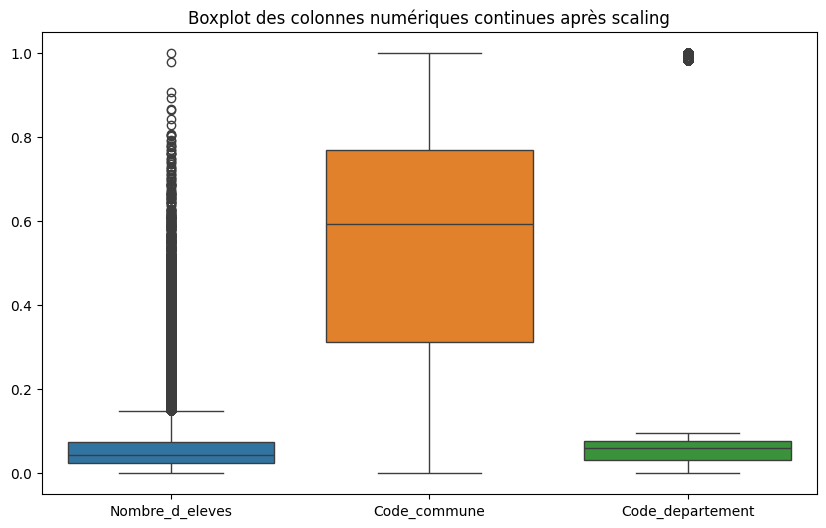

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

# Colonnes scalées
cols_to_plot = ['Nombre_d_eleves', 'Code_commune', 'Code_departement']

# Boxplot
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset[cols_to_plot])
plt.title("Boxplot des colonnes numériques continues après scaling")
plt.show()


In [68]:
import pandas as pd

# S'assurer que la colonne est bien en format datetime
dataset['date_ouverture'] = pd.to_datetime(dataset['date_ouverture'], errors='coerce')

# Extraire l'année et le mois
dataset['annee_ouverture'] = dataset['date_ouverture'].dt.year
dataset['mois_ouverture'] = dataset['date_ouverture'].dt.month

# Supprimer la colonne originale si tu ne veux plus la garder
# dataset.drop('date_ouverture', axis=1, inplace=True)

# Vérification du résultat
print(dataset[['date_ouverture', 'annee_ouverture', 'mois_ouverture']].head())


  date_ouverture  annee_ouverture  mois_ouverture
0     2018-09-01             2018               9
1     2019-09-01             2019               9
2     2015-09-01             2015               9
3     1965-07-12             1965               7
4     1966-10-14             1966              10


In [69]:
print(dataset.columns)


Index(['Code_postal', 'Code_commune', 'Code_departement', 'Code_academie',
       'Code_region', 'Voie_generale', 'Voie_technologique',
       'Voie_professionnelle', 'Restauration', 'Hebergement', 'ULIS',
       'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts',
       'Section_cinema', 'Section_theatre', 'Section_sport',
       'Section_internationale', 'Section_europeenne', 'Lycee_Agricole',
       'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'date_ouverture',
       'rpi_concentre', 'code_nature', 'OUVERT', 'Aucune', 'Privé', 'Public',
       'CONTRAT ASSOCIATION PARTIE DES CLASSES',
       'CONTRAT D'ASSOCIATION TOUTES CLASSES', 'CONTRAT SIMPLE TOUTES CLASSES',
       'HORS CONTRAT', 'SANS OBJET', 'EREA', 'Ecole',
       'Information et orientation', 'Lycée', 'Service Administratif', 'REP',
       'REP+', 'REP-', 'CENTRE D INFORMATION ET D ORIENTATION', 'CETAD (TOM)',
       'CIRCONSCRIPTIONS INSPECTION EDUC NAT', 'COLLEGE', 'COLLEGE CLIMATIQUE',
       'COLLEGE SPEC

In [70]:
# Supprimer complètement la colonne date_ouverture
dataset = dataset.drop(columns=['date_ouverture'])


In [72]:
import gc

gc.collect()

try:
    torch.cuda.empty_cache()
except:
    pass


In [73]:
print(dataset.columns)


Index(['Code_postal', 'Code_commune', 'Code_departement', 'Code_academie',
       'Code_region', 'Voie_generale', 'Voie_technologique',
       'Voie_professionnelle', 'Restauration', 'Hebergement', 'ULIS',
       'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts',
       'Section_cinema', 'Section_theatre', 'Section_sport',
       'Section_internationale', 'Section_europeenne', 'Lycee_Agricole',
       'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'rpi_concentre',
       'code_nature', 'OUVERT', 'Aucune', 'Privé', 'Public',
       'CONTRAT ASSOCIATION PARTIE DES CLASSES',
       'CONTRAT D'ASSOCIATION TOUTES CLASSES', 'CONTRAT SIMPLE TOUTES CLASSES',
       'HORS CONTRAT', 'SANS OBJET', 'EREA', 'Ecole',
       'Information et orientation', 'Lycée', 'Service Administratif', 'REP',
       'REP+', 'REP-', 'CENTRE D INFORMATION ET D ORIENTATION', 'CETAD (TOM)',
       'CIRCONSCRIPTIONS INSPECTION EDUC NAT', 'COLLEGE', 'COLLEGE CLIMATIQUE',
       'COLLEGE SPECIALISE', 'DIRECTIO

In [74]:
# Remplacer les NaN par la médiane de chaque colonne
dataset['Code_commune'] = dataset['Code_commune'].fillna(dataset['Code_commune'].median())
dataset['Code_departement'] = dataset['Code_departement'].fillna(dataset['Code_departement'].median())


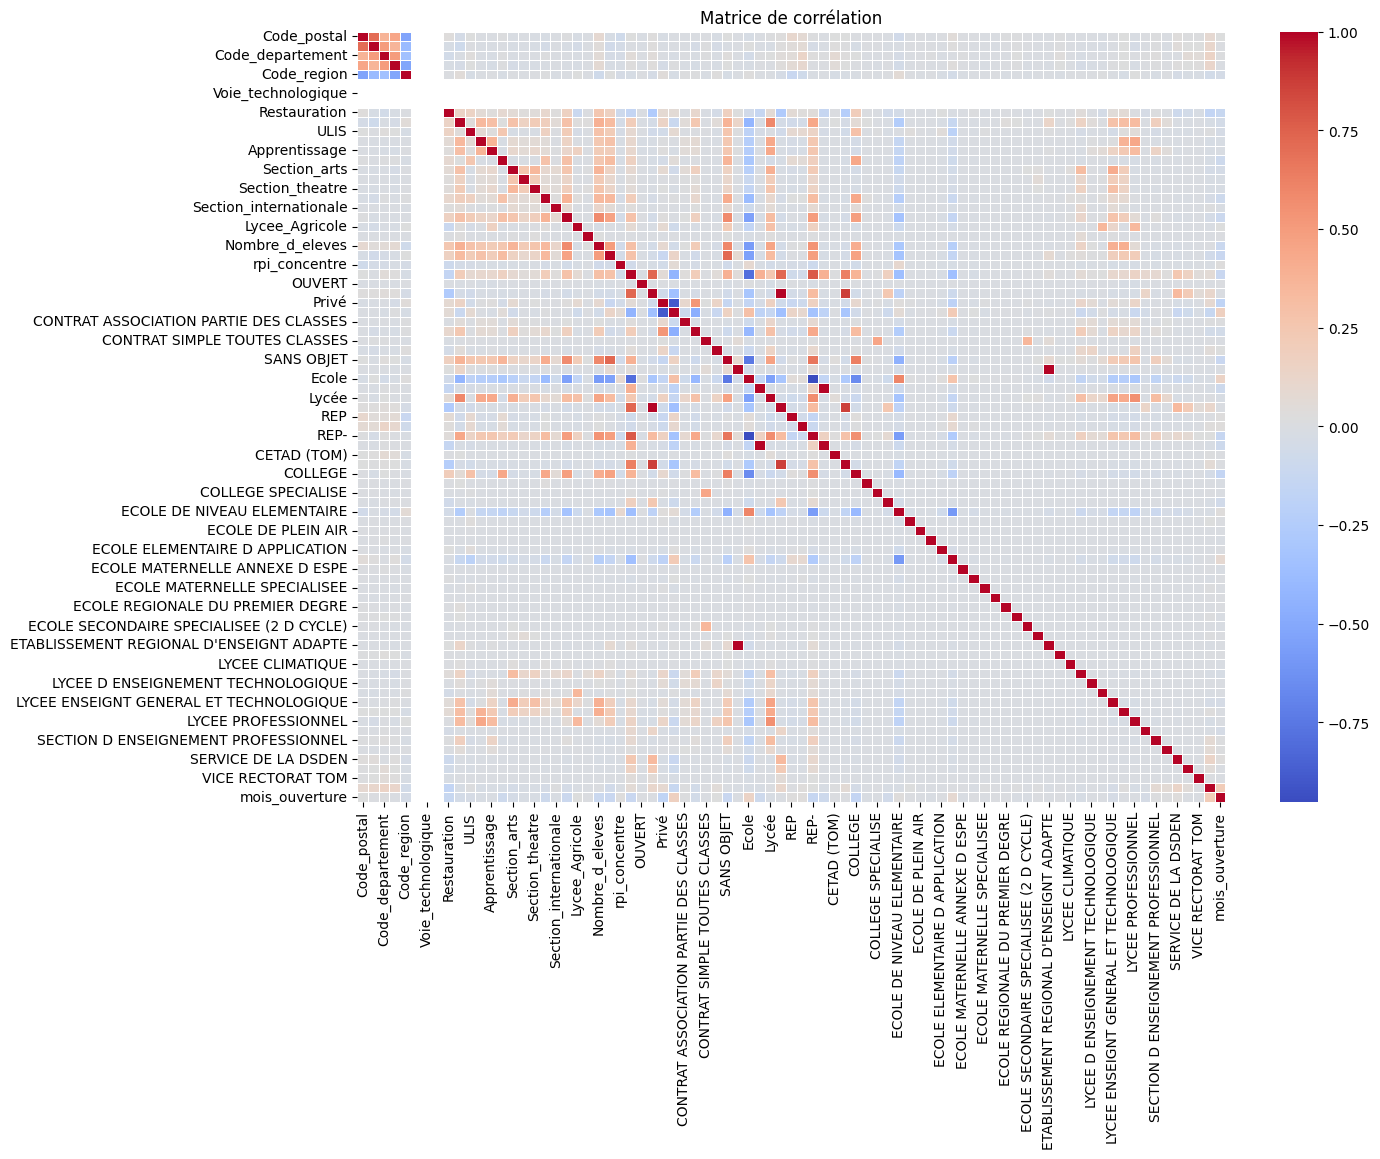

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 4) Calcul de la matrice de corrélation
corr_matrix = dataset.corr()

# 5) Affichage de la matrice (heatmap)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Matrice de corrélation")
plt.show()

In [76]:
# créer un masque pour ne garder que la moitié supérieure de la matrice
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# trouver les colonnes à supprimer
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
print("Features à supprimer :", to_drop)

Features à supprimer : ['Service Administratif', 'CENTRE D INFORMATION ET D ORIENTATION', 'CIRCONSCRIPTIONS INSPECTION EDUC NAT', "ETABLISSEMENT REGIONAL D'ENSEIGNT ADAPTE"]


In [77]:
# supprimer les colonnes fortement corrélées
df_reduced = dataset.drop(columns=to_drop)

# vérifier la nouvelle forme du DataFrame
print("Nouvelles dimensions :", df_reduced.shape)


Nouvelles dimensions : (64470, 77)


In [78]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [79]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reduced)


In [81]:
df_reduced = df_reduced.dropna()


In [82]:
df_reduced.isnull().sum()

Code_postal            0
Code_commune           0
Code_departement       0
Code_academie          0
Code_region            0
                      ..
SERVICE DE LA DSDEN    0
SERVICE RECTORAL       0
VICE RECTORAT TOM      0
annee_ouverture        0
mois_ouverture         0
Length: 77, dtype: int64

In [83]:
df_reduced = df_reduced.dropna()


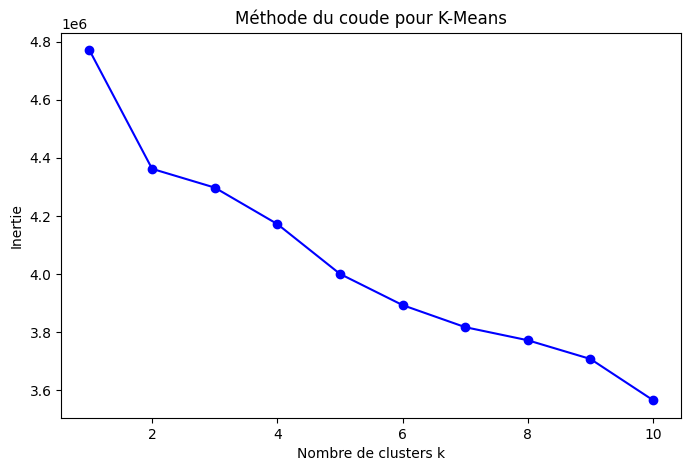

In [85]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Re-create X_scaled from the cleaned df_reduced DataFrame
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_reduced)

inertia = []
K_range = range(1, 11)  # On teste k de 1 à 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# tracer le graphique du coude
plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title("Méthode du coude pour K-Means")
plt.show()

In [86]:
from sklearn.cluster import KMeans

# créer le modèle avec k=2
kmeans = KMeans(n_clusters=2, random_state=42)


In [87]:
kmeans.fit(X_scaled)

KMeans(n_clusters=2, random_state=42)

In [88]:
labels = kmeans.labels_  # chaque ligne de ton dataset obtient un cluster (0,1,2)
dataset['Cluster'] = labels  # si tu veux l’ajouter à ton dataset


In [89]:
centers = kmeans.cluster_centers_
print("Centres des clusters :\n", centers)


Centres des clusters :
 [[-6.85680185e-03  1.37191091e-02 -1.46697632e-02 -1.42364397e-03
   6.64153829e-03  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -9.79244811e-02 -2.24681118e-01 -1.10015267e-01 -1.22815975e-01
  -1.24432652e-01 -1.54498045e-01 -1.12092762e-01 -5.87823143e-02
  -7.60783925e-02 -2.02685201e-01 -4.26391494e-02 -2.87910431e-01
  -8.32747428e-02 -7.87706871e-03 -3.02567397e-01 -2.87183263e-01
   3.77191071e-02 -2.22014828e-01  6.82168870e-03  3.72756775e-02
  -9.12258768e-02  6.43385441e-02 -4.31833517e-02 -2.15573634e-01
  -7.87706871e-03 -5.43674378e-02 -3.97713304e-01 -3.48041750e-02
   4.31666109e-01  1.87951837e-02 -2.86010777e-01  1.30957923e-02
   1.52040830e-02 -4.02685870e-01 -1.47377893e-02 -3.49528235e-01
  -5.56984230e-03 -8.80689886e-03  9.08822116e-03  2.58396883e-01
   4.49665118e-03  1.79836749e-03  1.55741985e-03  1.48880482e-02
   1.18876390e-01  1.27161812e-03  8.67740596e-03  1.55741985e-03
   1.27161812e-03  2.84360100e-03  2.20257552e-03 -5

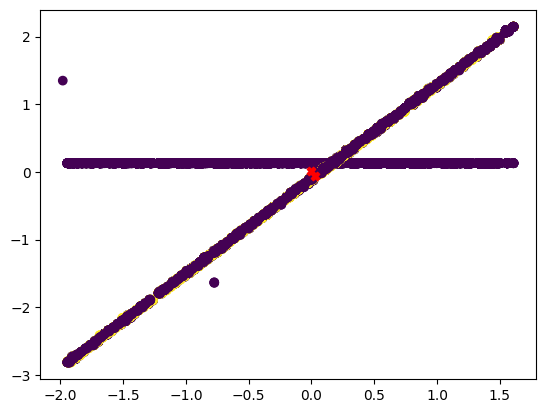

In [90]:
import matplotlib.pyplot as plt

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels, cmap='viridis')
plt.scatter(centers[:,0], centers[:,1], c='red', marker='X')  # centres
plt.show()


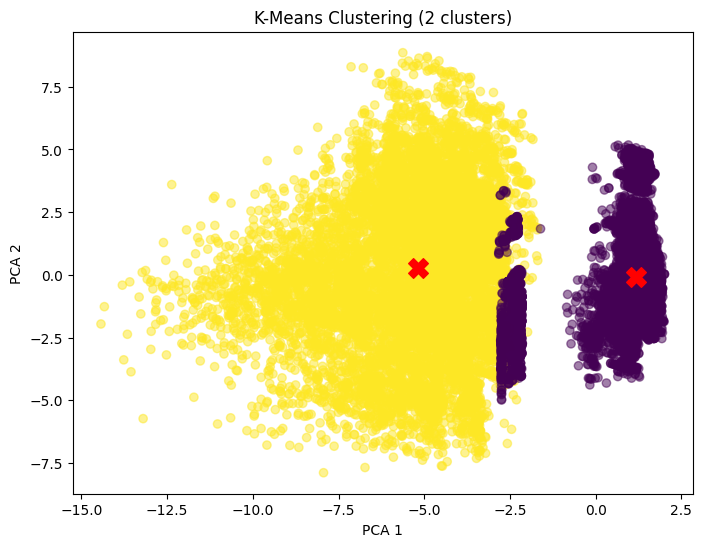

In [91]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Réduction dimensionnelle
pca = PCA(n_components=2)
data_2d = pca.fit_transform(X_scaled)
centers_2d = pca.transform(centers)

# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(data_2d[:,0], data_2d[:,1], c=labels, cmap='viridis', alpha=0.5)
plt.scatter(centers_2d[:,0], centers_2d[:,1], c='red', marker='X', s=200)
plt.title("K-Means Clustering (2 clusters)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


In [92]:
from sklearn.cluster import KMeans

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Vérifier les clusters
unique, counts = np.unique(labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster} : {count} points")


Cluster 0 : 52487 points
Cluster 1 : 11983 points


In [93]:
import pandas as pd

# créer un DataFrame avec noms de colonnes génériques
df = pd.DataFrame(X_scaled, columns=[f'feat_{i}' for i in range(X_scaled.shape[1])])

# ajouter la colonne des clusters
df['cluster'] = labels


In [94]:
# moyenne de chaque feature pour chaque cluster
cluster_summary = df.groupby('cluster').mean()
print(cluster_summary)


           feat_0    feat_1    feat_2    feat_3    feat_4  feat_5  feat_6  \
cluster                                                                     
0       -0.006857  0.013719 -0.014670 -0.001424  0.006642     0.0     0.0   
1        0.030034 -0.060091  0.064255  0.006236 -0.029091     0.0     0.0   

         feat_7    feat_8    feat_9  ...   feat_67   feat_68   feat_69  \
cluster                              ...                                 
0           0.0 -0.097924 -0.224681  ... -0.121705 -0.158555  0.004843   
1           0.0  0.428921  0.984131  ...  0.533083  0.694488 -0.021214   

          feat_70   feat_71   feat_72   feat_73   feat_74   feat_75   feat_76  
cluster                                                                        
0       -0.089999 -0.030008  0.012314  0.008197  0.002203  0.012926  0.062339  
1        0.394207  0.131437 -0.053935 -0.035904 -0.009648 -0.056615 -0.273054  

[2 rows x 77 columns]


In [95]:
# Supposons que ton dataset original s'appelle `df_original`
# et qu'après suppression des colonnes corrélées, tu as gardé :
selected_columns = df_reduced.columns  # Utiliser les colonnes de df_reduced

# Créer le DataFrame avec les vrais noms
df = pd.DataFrame(X_scaled, columns=selected_columns)
df['cluster'] = labels

# Calcul des features les plus discriminantes
cluster_summary = df.groupby('cluster').mean()
feature_diff = cluster_summary.max() - cluster_summary.min()
feature_diff = feature_diff.sort_values(ascending=False)

# Afficher les vrais noms de features
print("Features les plus discriminantes :")
for feat, diff in feature_diff.head(10).items():
    print(f"{feat} : {diff:.4f}")

Features les plus discriminantes :
Ecole : 2.3224
REP- : 2.1665
SANS OBJET : 2.1397
COLLEGE : 1.8805
Nombre_d_eleves : 1.6278
Section_europeenne : 1.5490
GRETA : 1.5451
Lycée : 1.5388
ECOLE DE NIVEAU ELEMENTAIRE : 1.3902
Hebergement : 1.2088


In [96]:
# Moyennes des features par cluster
cluster_summary_selected = df.groupby('cluster')[feature_diff.head(10).index].mean()
print(cluster_summary_selected)


            Ecole      REP-  SANS OBJET   COLLEGE  Nombre_d_eleves  \
cluster                                                              
0        0.431666 -0.402686   -0.397713 -0.349528        -0.302567   
1       -1.890750  1.763813    1.742033  1.530976         1.325282   

         Section_europeenne     GRETA     Lycée  ECOLE DE NIVEAU ELEMENTAIRE  \
cluster                                                                        
0                 -0.287910 -0.287183 -0.286011                     0.258397   
1                  1.261083  1.257898  1.252762                    -1.131810   

         Hebergement  
cluster               
0          -0.224681  
1           0.984131  


Les valeurs positives → la feature est plus élevée dans le cluster 1.

Les valeurs négatives → la feature est plus élevée dans le cluster 0.

In [97]:
cluster_diff = cluster_summary_selected.loc[1] - cluster_summary_selected.loc[0]
print("Différence moyenne cluster 1 - cluster 0 :")
print(cluster_diff)


Différence moyenne cluster 1 - cluster 0 :
Ecole                         -2.322416
REP-                           2.166499
SANS OBJET                     2.139746
COLLEGE                        1.880504
Nombre_d_eleves                1.627849
Section_europeenne             1.548993
GRETA                          1.545081
Lycée                          1.538773
ECOLE DE NIVEAU ELEMENTAIRE   -1.390207
Hebergement                    1.208812
dtype: float64


0


In [109]:
import pickle

# Sauvegarder le modèle KMeans
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Sauvegarder le scaler
with open('kmeans_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Sauvegarder les noms des features
with open('kmeans_feature_names.pkl', 'wb') as f:
    pickle.dump(list(df_reduced.columns), f)

print("✅ Modèle KMeans + scaler + features sauvegardés avec succès !")


✅ Modèle KMeans + scaler + features sauvegardés avec succès !


In [112]:
import pandas as pd
import numpy as np

# Liste complète des colonnes attendues par ton modèle
features_kmeans = [
    # Groupe 1 : colonnes structure école
    'Code_postal', 'Code_commune', 'Code_departement', 'Code_academie', 'Code_region',
    'Voie_generale', 'Voie_technologique', 'Voie_professionnelle', 'Restauration', 'Hebergement',
    'ULIS', 'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts', 'Section_cinema',
    'Section_theatre', 'Section_sport', 'Section_internationale', 'Section_europeenne',
    'Lycee_Agricole', 'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'rpi_concentre',
    'code_nature', 'LYCEE ENSEIGNT GENERAL ET TECHNOLOGIQUE',
    # Groupe 2 : colonnes types/contrats
    'OUVERT', 'Aucune', 'Privé', 'Public', 'CONTRAT ASSOCIATION PARTIE DES CLASSES',
    "CONTRAT D'ASSOCIATION TOUTES CLASSES", 'CONTRAT SIMPLE TOUTES CLASSES', 'HORS CONTRAT',
    'SANS OBJET', 'EREA', 'Ecole', 'Information et orientation', 'Lycée', 'REP', 'REP+', 'REP-',
    'CETAD (TOM)', 'COLLEGE', 'COLLEGE CLIMATIQUE', 'COLLEGE SPECIALISE',
    'DIRECTION SERVICES DEPARTEMENTAUX EN', 'ECOLE DE NIVEAU ELEMENTAIRE',
    'ECOLE DE NIVEAU ELEMENTAIRE SPECIALISEE', 'ECOLE DE PLEIN AIR',
    'ECOLE ELEMENTAIRE ANNEXE D ESPE', 'ECOLE ELEMENTAIRE D APPLICATION', 'ECOLE MATERNELLE',
    'ECOLE MATERNELLE ANNEXE D ESPE', 'ECOLE MATERNELLE D APPLICATION', 'ECOLE MATERNELLE SPECIALISEE',
    'ECOLE PRIMAIRE FRANCAISE', 'ECOLE REGIONALE DU PREMIER DEGRE',
    'ECOLE SANS EFFECTIFS PERMANENTS', 'ECOLE SECONDAIRE SPECIALISEE (2 D CYCLE)',
    'ETABLISSEMENT EXPERIMENTAL', 'GROUPEMENT D OBSERVATION DISPERSE', 'LYCEE CLIMATIQUE',
    'LYCEE D ENSEIGNEMENT GENERAL', 'LYCEE D ENSEIGNEMENT TECHNOLOGIQUE',
    'LYCEE ENS GENERAL TECHNO PROF AGRICOLE', 'LYCEE POLYVALENT', 'LYCEE PROFESSIONNEL',
    'RECTORAT', 'SECTION D ENSEIGNEMENT PROFESSIONNEL', 'SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE',
    'SERVICE DE LA DSDEN', 'SERVICE RECTORAL', 'VICE RECTORAT TOM', 'annee_ouverture', 'mois_ouverture'
]

# Nombre de lignes de test
n_rows = 50

# Génération des valeurs aléatoires
data = {}
for col in features_kmeans:
    if 'Code' in col or 'Nombre' in col or 'annee' in col.lower() or 'mois' in col.lower():
        data[col] = np.random.randint(1, 1000, size=n_rows)
    else:
        # Colonnes binaires 0/1 pour présence / absence
        data[col] = np.random.randint(0, 2, size=n_rows)

# Création du DataFrame
df_test = pd.DataFrame(data)

# Sauvegarde en CSV
df_test.to_csv("test_kmeans_complet.csv", index=False, encoding='utf-8')

print("CSV complet pour test K-Means généré : test_kmeans_complet.csv")


CSV complet pour test K-Means généré : test_kmeans_complet.csv


In [118]:
import pandas as pd
import numpy as np

# Liste des colonnes attendues par le modèle
features_kmeans = [
    'Code_postal', 'Code_commune', 'Code_departement', 'Code_academie', 'Code_region',
    'Voie_generale', 'Voie_technologique', 'Voie_professionnelle', 'Restauration', 'Hebergement',
    'ULIS', 'Lycee_des_metiers', 'Apprentissage', 'Segpa', 'Section_arts', 'Section_cinema',
    'Section_theatre', 'Section_sport', 'Section_internationale', 'Section_europeenne',
    'Lycee_Agricole', 'Lycee_militaire', 'Nombre_d_eleves', 'GRETA', 'rpi_concentre',
    'code_nature', 'LYCEE ENSEIGNT GENERAL ET TECHNOLOGIQUE',
    'OUVERT', 'Aucune', 'Privé', 'Public', 'CONTRAT ASSOCIATION PARTIE DES CLASSES',
    "CONTRAT D'ASSOCIATION TOUTES CLASSES", 'CONTRAT SIMPLE TOUTES CLASSES', 'HORS CONTRAT',
    'SANS OBJET', 'EREA', 'Ecole', 'Information et orientation', 'Lycée', 'REP', 'REP+', 'REP-',
    'CETAD (TOM)', 'COLLEGE', 'COLLEGE CLIMATIQUE', 'COLLEGE SPECIALISE',
    'DIRECTION SERVICES DEPARTEMENTAUX EN', 'ECOLE DE NIVEAU ELEMENTAIRE',
    'ECOLE DE NIVEAU ELEMENTAIRE SPECIALISEE', 'ECOLE DE PLEIN AIR',
    'ECOLE ELEMENTAIRE ANNEXE D ESPE', 'ECOLE ELEMENTAIRE D APPLICATION', 'ECOLE MATERNELLE',
    'ECOLE MATERNELLE ANNEXE D ESPE', 'ECOLE MATERNELLE D APPLICATION', 'ECOLE MATERNELLE SPECIALISEE',
    'ECOLE PRIMAIRE FRANCAISE', 'ECOLE REGIONALE DU PREMIER DEGRE',
    'ECOLE SANS EFFECTIFS PERMANENTS', 'ECOLE SECONDAIRE SPECIALISEE (2 D CYCLE)',
    'ETABLISSEMENT EXPERIMENTAL', 'GROUPEMENT D OBSERVATION DISPERSE', 'LYCEE CLIMATIQUE',
    'LYCEE D ENSEIGNEMENT GENERAL', 'LYCEE D ENSEIGNEMENT TECHNOLOGIQUE',
    'LYCEE ENS GENERAL TECHNO PROF AGRICOLE', 'LYCEE POLYVALENT', 'LYCEE PROFESSIONNEL',
    'RECTORAT', 'SECTION D ENSEIGNEMENT PROFESSIONNEL', 'SECTION ENSEIGT GENERAL ET TECHNOLOGIQUE',
    'SERVICE DE LA DSDEN', 'SERVICE RECTORAL', 'VICE RECTORAT TOM', 'annee_ouverture', 'mois_ouverture'
]

# Nombre de lignes pour ce dataset
n_rows = 50

# Génération aléatoire des données
data = {}
for col in features_kmeans:
    if 'Code_postal' in col:
        # Codes postaux français réalistes
        data[col] = np.random.randint(1000, 98000, size=n_rows)
    elif 'Code_commune' in col or 'Code_departement' in col or 'Code_academie' in col or 'Code_region' in col:
        data[col] = np.random.randint(1, 1000, size=n_rows)
    elif 'Nombre' in col:
        data[col] = np.random.randint(50, 2000, size=n_rows)  # Nombre d'élèves réaliste
    elif 'annee' in col.lower():
        data[col] = np.random.randint(1950, 2025, size=n_rows)
    elif 'mois' in col.lower():
        data[col] = np.random.randint(1, 13, size=n_rows)
    else:
        # Colonnes binaires aléatoires
        data[col] = np.random.choice([0, 1], size=n_rows, p=[0.6, 0.4])  # léger déséquilibre

# Création du DataFrame
df_new_test = pd.DataFrame(data)

# Sauvegarde en CSV
df_new_test.to_csv("test_kmeans_alternatif.csv", index=False, encoding='utf-8')

print("✅ CSV alternatif pour test K-Means généré : test_kmeans_alternatif.csv")


✅ CSV alternatif pour test K-Means généré : test_kmeans_alternatif.csv


🎉 Nouveau CSV de test K-Means généré : test_kmeans_complet_nouveau.csv

--- Aperçu des données générées ---
   Code_postal  Code_commune  Code_departement  Code_academie  Code_region  \
0          103           958               556            490          900   
1          436           563               162            231          734   
2          861           876               202             41          485   
3          271           567               958             28          407   
4          107           244               996            135          231   

   Voie_generale  Voie_technologique  Voie_professionnelle  Restauration  \
0              0                   1                     0             1   
1              0                   1                     1             0   
2              1                   0                     0             1   
3              0                   1                     0             1   
4              0                   0       